# 📊 BIRS Interest Rate Swap — Exploratory Data Analysis

**BIRS** (Budapest Interest Rate Swap) is the Hungarian reference rate for interest rate swaps, published daily by the Magyar Nemzeti Bank (MNB).

This notebook explores the full BIRS dataset from **2006 to 2026**, covering tenors from 2 to 20 years.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Color palette for tenors
COLORS = plt.cm.viridis(np.linspace(0.1, 0.95, 12))

# Load data
df = pd.read_pickle('birs_flat.pkl')
df['date of fixing'] = pd.to_datetime(df['date of fixing'])
df = df.sort_values('date of fixing').reset_index(drop=True)

# Tenor columns (numeric data)
tenor_cols = [c for c in df.columns if 'years' in c]
tenor_cols.sort(key=lambda x: int(x.split()[0]))

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date of fixing'].min().date()} → {df['date of fixing'].max().date()}")
print(f"Tenors: {tenor_cols}")

Dataset loaded: 4,940 rows × 14 columns
Date range: 2006-11-15 → 2026-06-08
Tenors: ['2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '10 years', '12 years', '15 years', '20 years']


## 1. Dataset Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4940 entries, 0 to 4939
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date of fixing  4940 non-null   datetime64[ns]
 1   2 years         4940 non-null   float64       
 2   3 years         4940 non-null   float64       
 3   4 years         4940 non-null   float64       
 4   5 years         4940 non-null   float64       
 5   6 years         4940 non-null   float64       
 6   7 years         4940 non-null   float64       
 7   8 years         4940 non-null   float64       
 8   9 years         4940 non-null   float64       
 9   10 years        4940 non-null   float64       
 10  12 years        4940 non-null   float64       
 11  15 years        4940 non-null   float64       
 12  20 years        1572 non-null   float64       
 13  source_sheet    4940 non-null   object        
dtypes: datetime64[ns](1), float64(12), object(1)
memory usag

In [3]:
df.describe().round(3)

,date of fixing,2 years,3 years,4 years,5 years,6 years,7 years,8 years,9 years,10 years,12 years,15 years,20 years
count,4940,4940.000,4940.000,4940.000,4940.000,4940.000,4940.000,4940.000,4940.000,4940.000,4940.000,4940.000,1572.000
mean,2016-08-21 19:46:23.805668096,4.837,4.788,4.794,4.835,4.892,4.954,5.014,5.067,5.108,5.153,5.161,5.777
min,2006-11-15 00:00:00,0.180,0.320,0.420,0.480,0.570,0.670,0.770,0.870,0.960,1.150,1.370,1.720
25%,2011-09-28 18:00:00,1.250,1.490,1.678,1.898,2.080,2.260,2.420,2.550,2.680,2.860,3.070,3.828
50%,2016-08-17 12:00:00,5.750,5.735,5.750,5.760,5.810,5.845,5.895,5.950,5.990,6.000,5.940,6.590
75%,2021-07-15 06:00:00,7.092,6.970,6.932,6.950,6.960,6.950,6.940,6.902,6.880,6.840,6.760,7.130
max,2026-06-08 00:00:00,16.400,15.100,13.920,12.980,12.360,11.870,11.570,11.350,11.180,11.020,10.970,10.990
std,NaN,3.470,3.188,2.980,2.817,2.687,2.577,2.483,2.399,2.323,2.197,2.059,2.167


In [4]:
# Missing values by tenor
missing = df[tenor_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
2 years,0,0.0
3 years,0,0.0
4 years,0,0.0
5 years,0,0.0
6 years,0,0.0
7 years,0,0.0
8 years,0,0.0
9 years,0,0.0
10 years,0,0.0
12 years,0,0.0


In [5]:
# Data availability by year
yearly_counts = df.groupby(df['date of fixing'].dt.year).size()
yearly_counts.name = 'Trading Days'
print(yearly_counts.to_string())
print(f"\nTotal observations: {len(df):,}")

date of fixing
2006     31
2007    252
2008    254
2009    254
2010    254
2011    255
2012    252
2013    251
2014    253
2015    254
2016    255
2017    251
2018    250
2019    250
2020    254
2021    254
2022    254
2023    251
2024    251
2025    252
2026    108

Total observations: 4,940


## 2. Full Rate History

All BIRS tenor rates plotted over the entire available history.

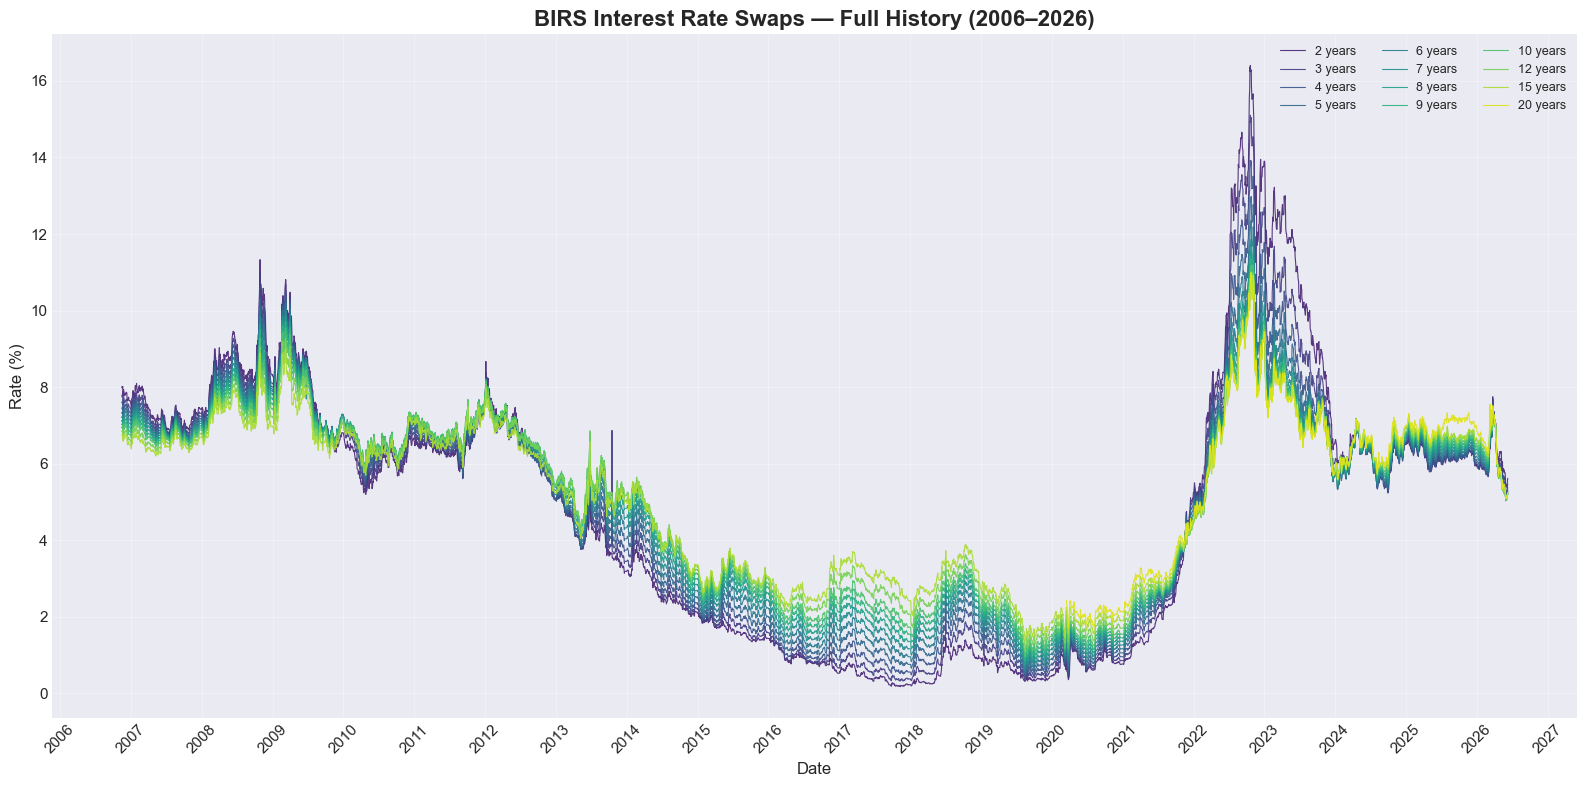

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

for i, col in enumerate(tenor_cols):
    mask = df[col].notna()
    ax.plot(df.loc[mask, 'date of fixing'], df.loc[mask, col],
            label=col, color=COLORS[i], linewidth=0.8, alpha=0.9)

ax.set_title('BIRS Interest Rate Swaps — Full History (2006–2026)', fontweight='bold', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Rate (%)')
ax.legend(loc='upper right', ncol=3, fontsize=9, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Yield Curve Snapshots

Cross-sectional view: the term structure at selected dates.

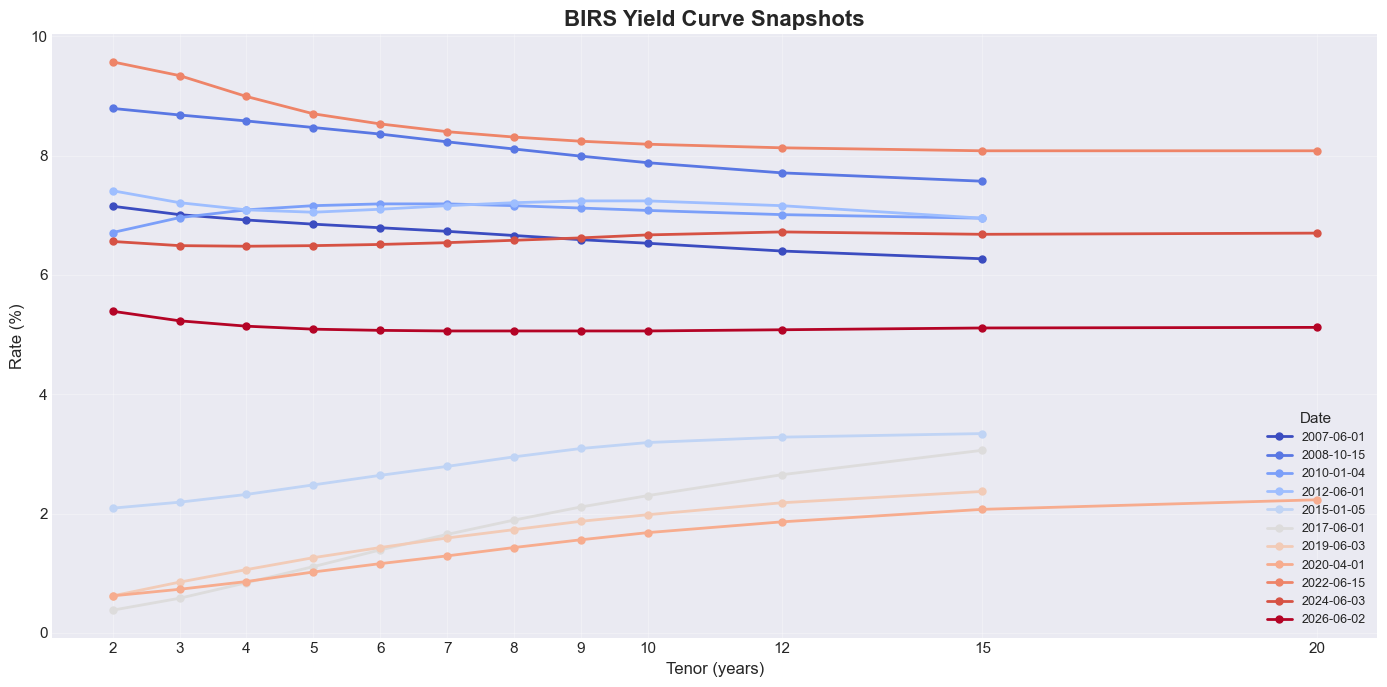

In [7]:
# Select representative dates across the history
snapshot_dates = ['2007-06-01', '2008-10-15', '2010-01-04', '2012-06-01',
                  '2015-01-05', '2017-06-01', '2019-06-03', '2020-04-01',
                  '2022-06-15', '2024-06-03', '2026-06-02']

fig, ax = plt.subplots(figsize=(14, 7))
cmap = plt.cm.coolwarm(np.linspace(0, 1, len(snapshot_dates)))

for i, date_str in enumerate(snapshot_dates):
    target = pd.Timestamp(date_str)
    # Find nearest available date
    idx = (df['date of fixing'] - target).abs().idxmin()
    row = df.loc[idx]
    actual_date = row['date of fixing'].strftime('%Y-%m-%d')

    tenors_num = [int(c.split()[0]) for c in tenor_cols]
    values = [row[c] for c in tenor_cols]

    # Filter out NaN
    valid = [(t, v) for t, v in zip(tenors_num, values) if pd.notna(v)]
    if valid:
        ts, vs = zip(*valid)
        ax.plot(ts, vs, 'o-', color=cmap[i], label=actual_date, linewidth=2, markersize=5)

ax.set_title('BIRS Yield Curve Snapshots', fontweight='bold', fontsize=16)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Rate (%)')
ax.set_xticks([int(c.split()[0]) for c in tenor_cols])
ax.legend(title='Date', loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Term Spread Analysis

The spread between long-tenor (10Y) and short-tenor (2Y) rates indicates the slope of the yield curve.
- **Positive spread** → normal (upward-sloping) curve
- **Negative spread** → inverted curve (often signals economic stress)

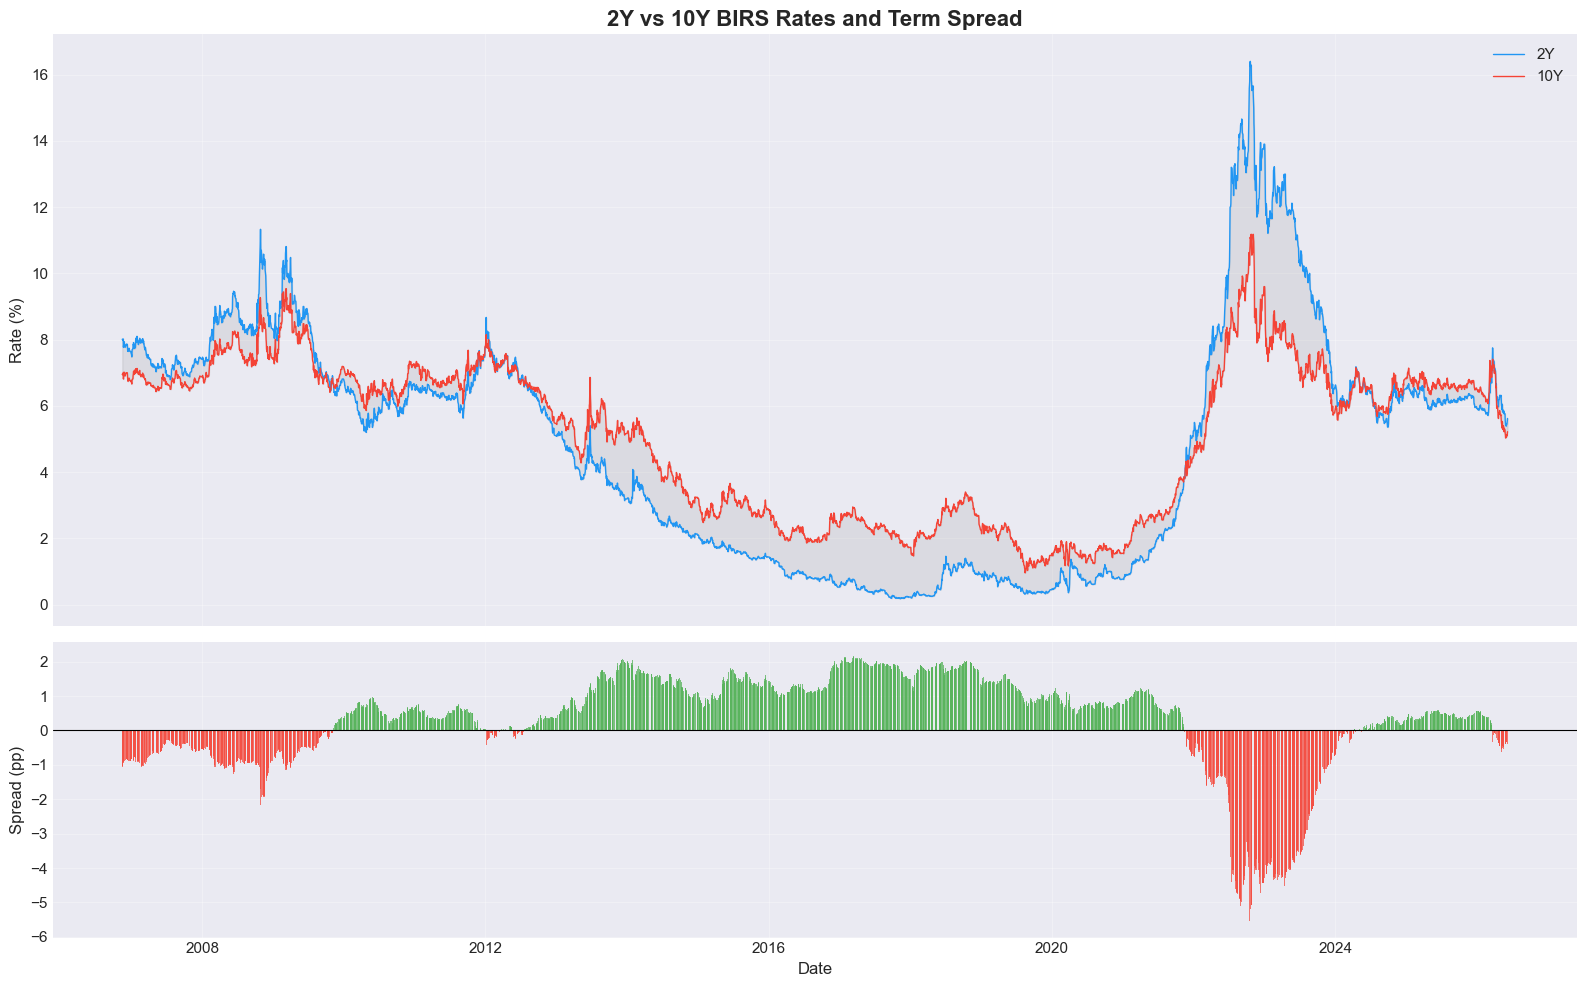

Spread statistics (10Y - 2Y):
count    4940.000
mean        0.272
std         1.417
min        -5.630
25%        -0.350
50%         0.530
75%         1.230
max         2.180

Days with inverted curve: 1519 (30.7%)


In [8]:
# 10Y - 2Y spread (only where both exist)
spread_mask = df['10 years'].notna() & df['2 years'].notna()
spread_df = df.loc[spread_mask].copy()
spread_df['spread_10y_2y'] = spread_df['10 years'] - spread_df['2 years']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# Top: rates
axes[0].plot(spread_df['date of fixing'], spread_df['2 years'],
             label='2Y', color='#2196F3', linewidth=1)
axes[0].plot(spread_df['date of fixing'], spread_df['10 years'],
             label='10Y', color='#F44336', linewidth=1)
axes[0].fill_between(spread_df['date of fixing'],
                     spread_df['2 years'], spread_df['10 years'],
                     alpha=0.15, color='gray')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('2Y vs 10Y BIRS Rates and Term Spread', fontweight='bold', fontsize=16)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Bottom: spread
colors = np.where(spread_df['spread_10y_2y'] >= 0, '#4CAF50', '#F44336')
axes[1].bar(spread_df['date of fixing'], spread_df['spread_10y_2y'],
            color=colors, width=2, alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('Spread (pp)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Spread statistics (10Y - 2Y):")
print(spread_df['spread_10y_2y'].describe().round(3).to_string())
print(f"\nDays with inverted curve: {(spread_df['spread_10y_2y'] < 0).sum()} "
      f"({(spread_df['spread_10y_2y'] < 0).mean()*100:.1f}%)")

## 5. Volatility Analysis

Rolling standard deviation of daily changes to identify periods of market stress.

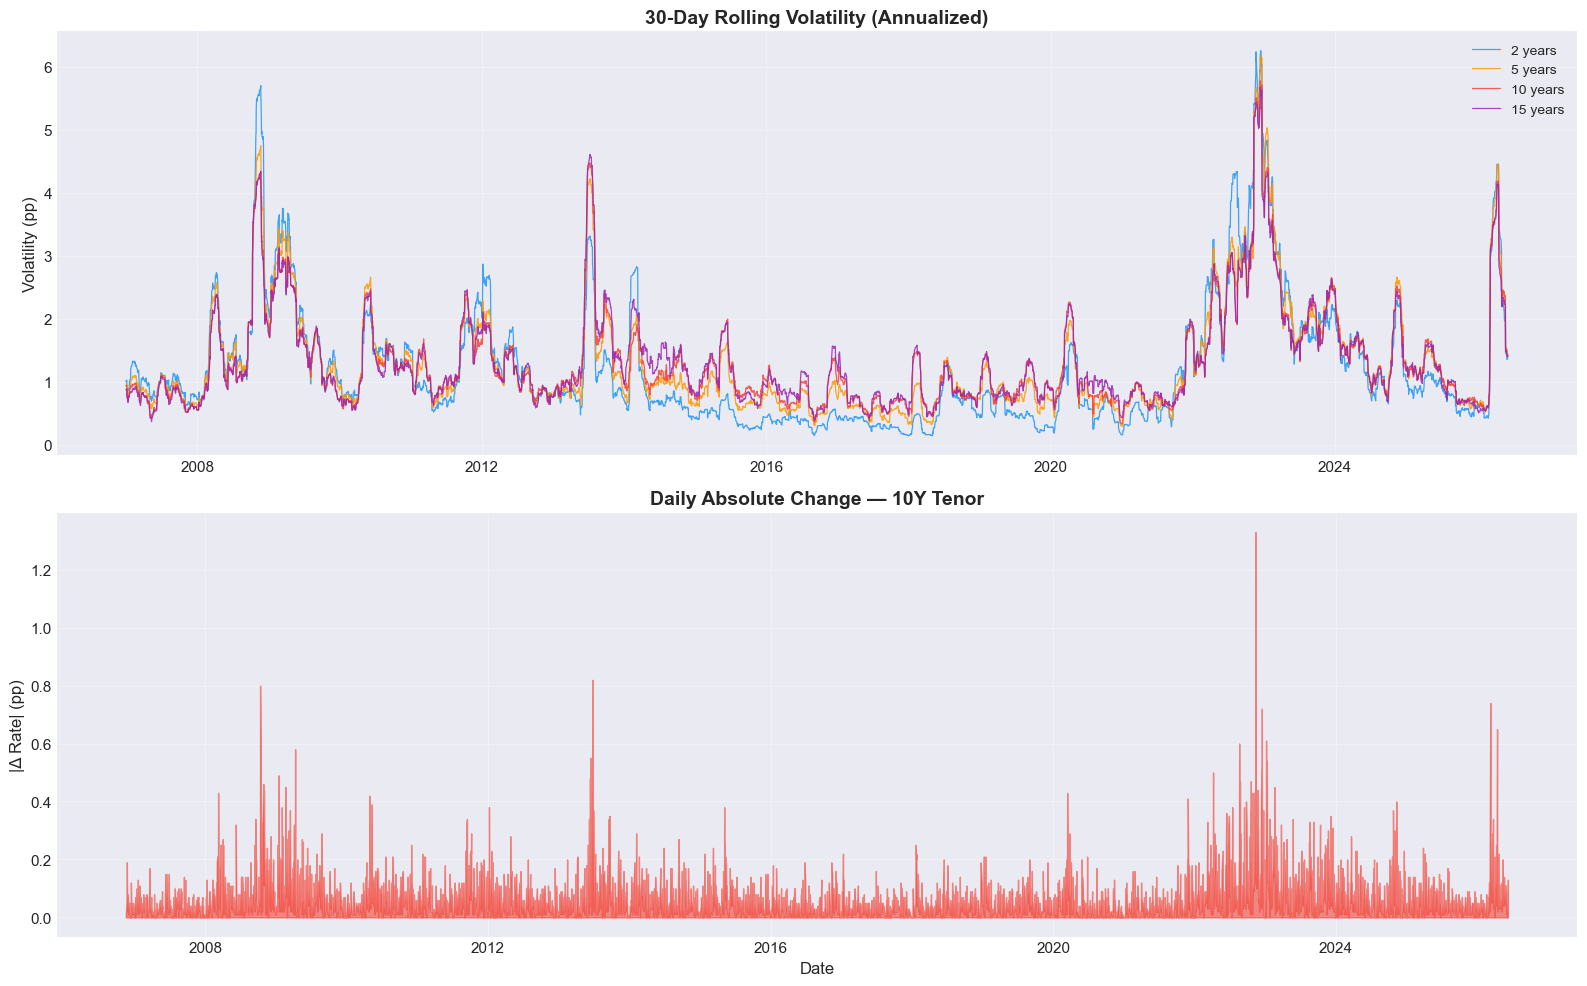

Top 10 largest daily moves (10Y):
  2022-11-11: ↓ 1.330 pp
  2013-06-24: ↑ 0.820 pp
  2008-10-10: ↑ 0.800 pp
  2026-03-09: ↑ 0.740 pp
  2022-12-14: ↓ 0.720 pp
  2026-03-10: ↓ 0.650 pp
  2026-04-13: ↓ 0.650 pp
  2023-01-05: ↓ 0.610 pp
  2022-08-19: ↑ 0.600 pp
  2008-10-13: ↓ 0.580 pp


In [9]:
# Daily changes
changes = df.set_index('date of fixing')[tenor_cols].diff()

# 30-day rolling volatility (annualized)
rolling_vol = changes.rolling(30).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Select key tenors for clarity
key_tenors = ['2 years', '5 years', '10 years', '15 years']
key_colors = ['#2196F3', '#FF9800', '#F44336', '#9C27B0']

for col, color in zip(key_tenors, key_colors):
    axes[0].plot(rolling_vol.index, rolling_vol[col],
                 label=col, color=color, linewidth=0.9, alpha=0.85)
axes[0].set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Volatility (pp)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Daily absolute changes heatmap-style for 10Y
abs_changes_10y = changes['10 years'].abs()
axes[1].fill_between(abs_changes_10y.index, 0, abs_changes_10y,
                     alpha=0.6, color='#F44336')
axes[1].set_title('Daily Absolute Change — 10Y Tenor', fontweight='bold', fontsize=14)
axes[1].set_ylabel('|Δ Rate| (pp)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Top 10 largest daily moves
print("Top 10 largest daily moves (10Y):")
top_moves = changes['10 years'].abs().nlargest(10)
for date, val in top_moves.items():
    direction = "↑" if changes.loc[date, '10 years'] > 0 else "↓"
    print(f"  {date.strftime('%Y-%m-%d')}: {direction} {val:.3f} pp")

## 6. Correlation Structure

How correlated are rate changes across different tenors?

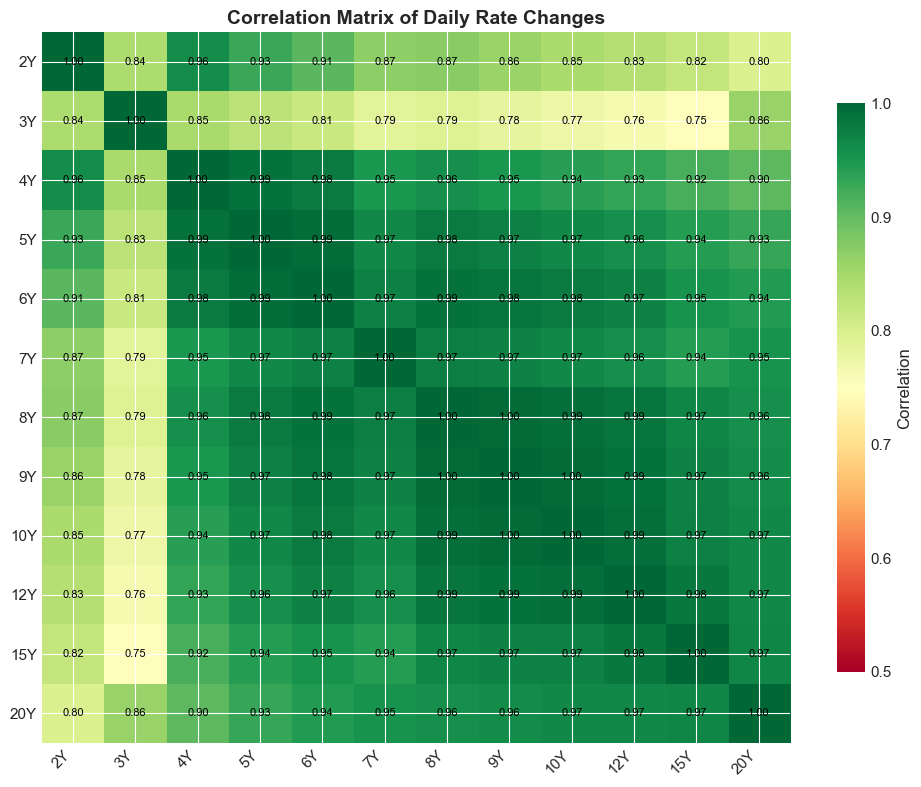

In [10]:
# Correlation of daily changes
corr = changes[tenor_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')

# Labels
labels = [c.replace(' years', 'Y') for c in tenor_cols]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

# Annotate
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if val > 0.7 else 'white')

ax.set_title('Correlation Matrix of Daily Rate Changes', fontweight='bold', fontsize=14)
fig.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
plt.tight_layout()
plt.show()

## 7. Distribution of Rate Levels and Changes

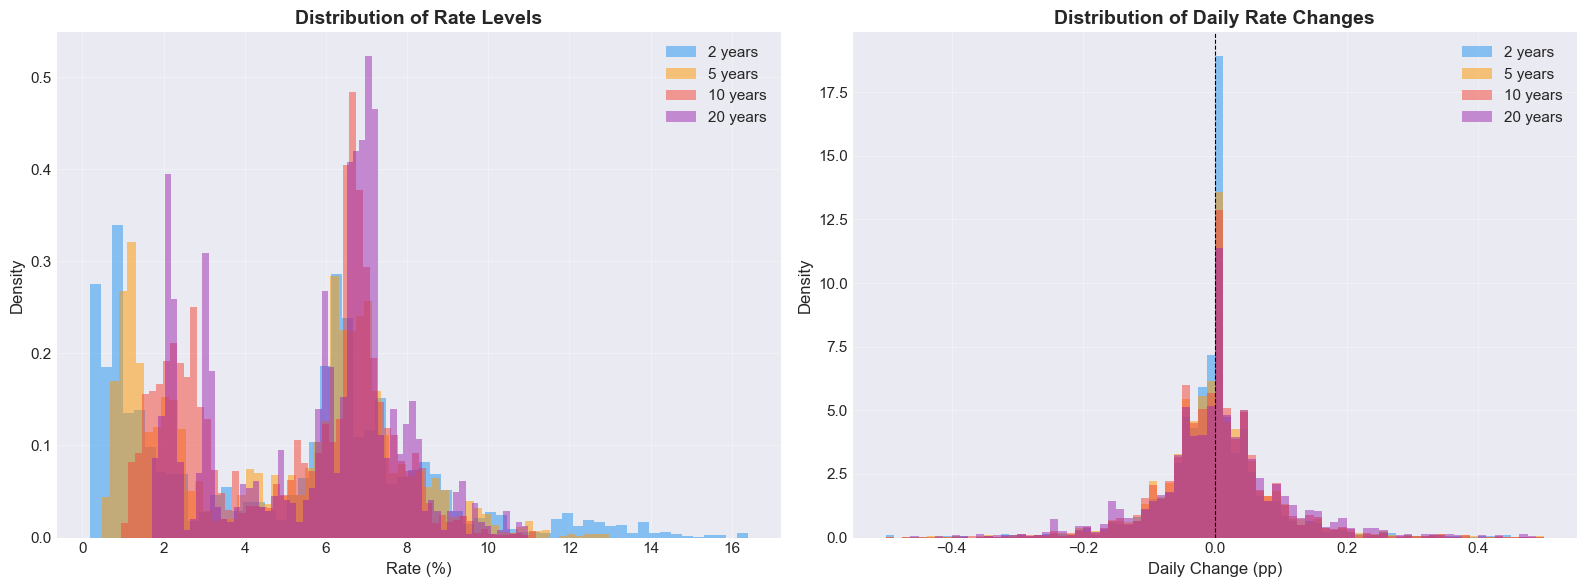

Daily changes — Skewness and Excess Kurtosis:
          Skewness  Excess Kurtosis  Mean (bp)  Std (bp)
2 years      0.365           17.993      -0.05      9.91
3 years     -0.251          196.825      -0.05     11.71
4 years     -0.081           16.674      -0.05      9.88
5 years     -0.238           16.506      -0.04      9.88
6 years     -0.260           15.570      -0.04      9.78
7 years     -0.111           16.933      -0.04      9.92
8 years     -0.262           15.177      -0.04      9.71
9 years     -0.284           15.033      -0.04      9.67
10 years    -0.349           15.645      -0.04      9.65
12 years    -0.319           15.759      -0.03      9.61
15 years    -0.299           14.801      -0.03      9.73
20 years    -0.922           14.716       0.18     11.91


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rate level distributions
key_tenors = ['2 years', '5 years', '10 years', '20 years']
key_colors = ['#2196F3', '#FF9800', '#F44336', '#9C27B0']

for col, color in zip(key_tenors, key_colors):
    data = df[col].dropna()
    axes[0].hist(data, bins=60, alpha=0.5, label=col, color=color, density=True)
axes[0].set_title('Distribution of Rate Levels', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Rate (%)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Daily change distributions
for col, color in zip(key_tenors, key_colors):
    data = changes[col].dropna()
    axes[1].hist(data, bins=80, alpha=0.5, label=col, color=color, density=True, range=(-0.5, 0.5))
axes[1].set_title('Distribution of Daily Rate Changes', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Daily Change (pp)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness and kurtosis
print("Daily changes — Skewness and Excess Kurtosis:")
stats = pd.DataFrame({
    'Skewness': changes[tenor_cols].skew().round(3),
    'Excess Kurtosis': changes[tenor_cols].kurtosis().round(3),
    'Mean (bp)': (changes[tenor_cols].mean() * 100).round(2),
    'Std (bp)': (changes[tenor_cols].std() * 100).round(2),
})
print(stats.to_string())

## 8. Rate Regime Analysis

Average rate levels and curve shape by year, revealing monetary policy regimes.

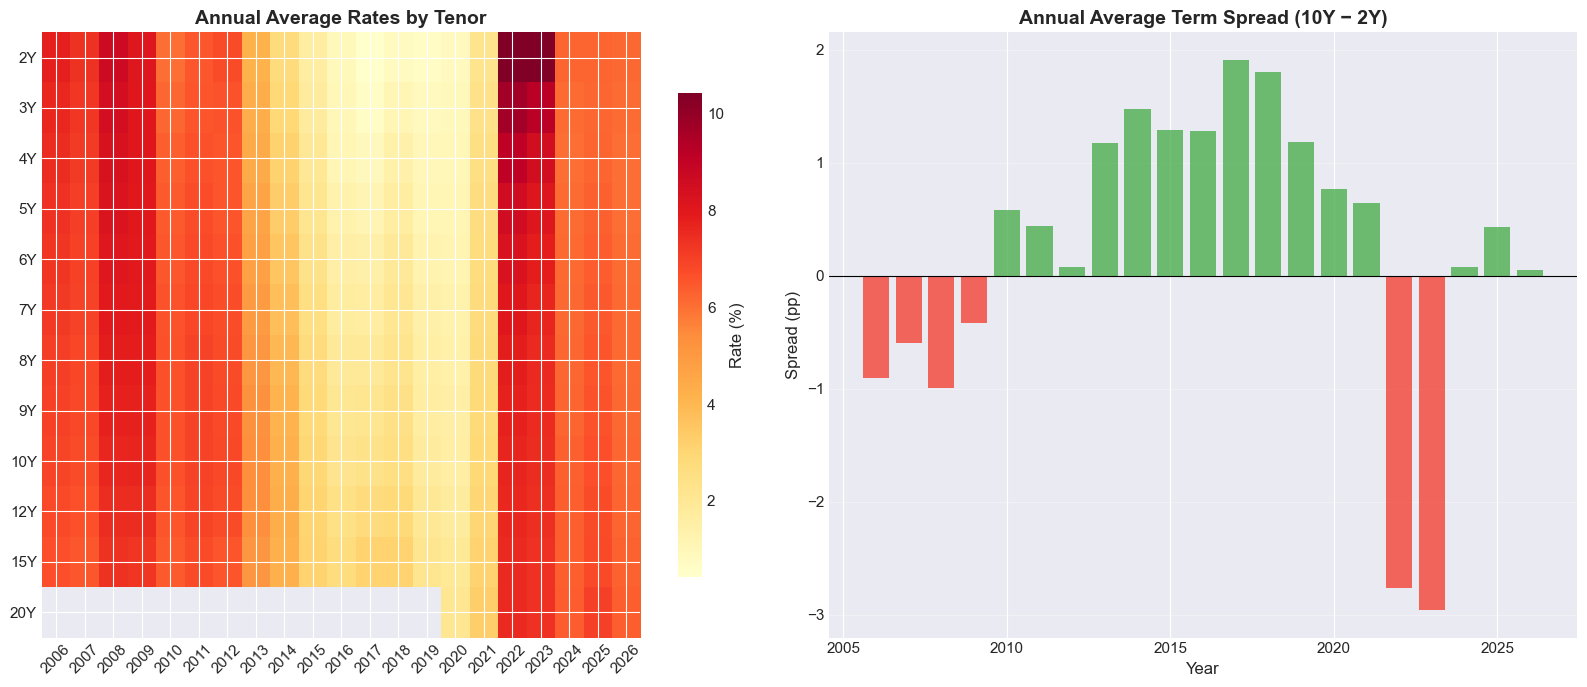

In [12]:
# Annual averages
df['year'] = df['date of fixing'].dt.year
annual_avg = df.groupby('year')[tenor_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap of annual average rates
available_tenors = [c for c in tenor_cols if annual_avg[c].notna().any()]
heatmap_data = annual_avg[available_tenors].T
labels_short = [c.replace(' years', 'Y') for c in available_tenors]

im = axes[0].imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
axes[0].set_yticks(range(len(labels_short)))
axes[0].set_yticklabels(labels_short)
axes[0].set_xticks(range(len(heatmap_data.columns)))
axes[0].set_xticklabels(heatmap_data.columns, rotation=45)
axes[0].set_title('Annual Average Rates by Tenor', fontweight='bold', fontsize=14)
fig.colorbar(im, ax=axes[0], shrink=0.8, label='Rate (%)')

# Annual average spread (10Y - 2Y)
if '10 years' in annual_avg.columns and '2 years' in annual_avg.columns:
    spread = annual_avg['10 years'] - annual_avg['2 years']
    spread = spread.dropna()
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in spread.values]
    axes[1].bar(spread.index, spread.values, color=colors, alpha=0.8)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_title('Annual Average Term Spread (10Y − 2Y)', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Spread (pp)')
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Monthly Patterns

Are there seasonal patterns in rate changes?

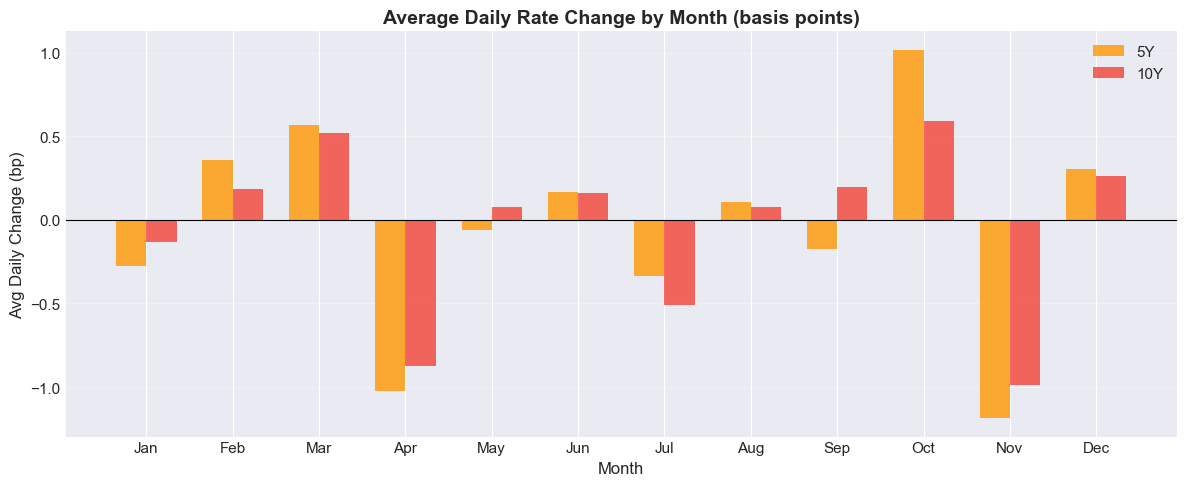

In [13]:
df_with_changes = df.copy()
for col in tenor_cols:
    df_with_changes[f'{col}_chg'] = df_with_changes[col].diff()

df_with_changes['month'] = df_with_changes['date of fixing'].dt.month

# Monthly average change for 5Y and 10Y
chg_cols = ['5 years_chg', '10 years_chg']
monthly_avg = df_with_changes.groupby('month')[chg_cols].mean() * 100  # in basis points

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, 13)
width = 0.35
bars1 = ax.bar(x - width/2, monthly_avg['5 years_chg'], width,
               label='5Y', color='#FF9800', alpha=0.8)
bars2 = ax.bar(x + width/2, monthly_avg['10 years_chg'], width,
               label='10Y', color='#F44336', alpha=0.8)

ax.set_title('Average Daily Rate Change by Month (basis points)', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Change (bp)')
ax.set_xticks(x)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 10. Recent Period Deep-Dive (Last 12 Months)

A closer look at the most recent rate movements.

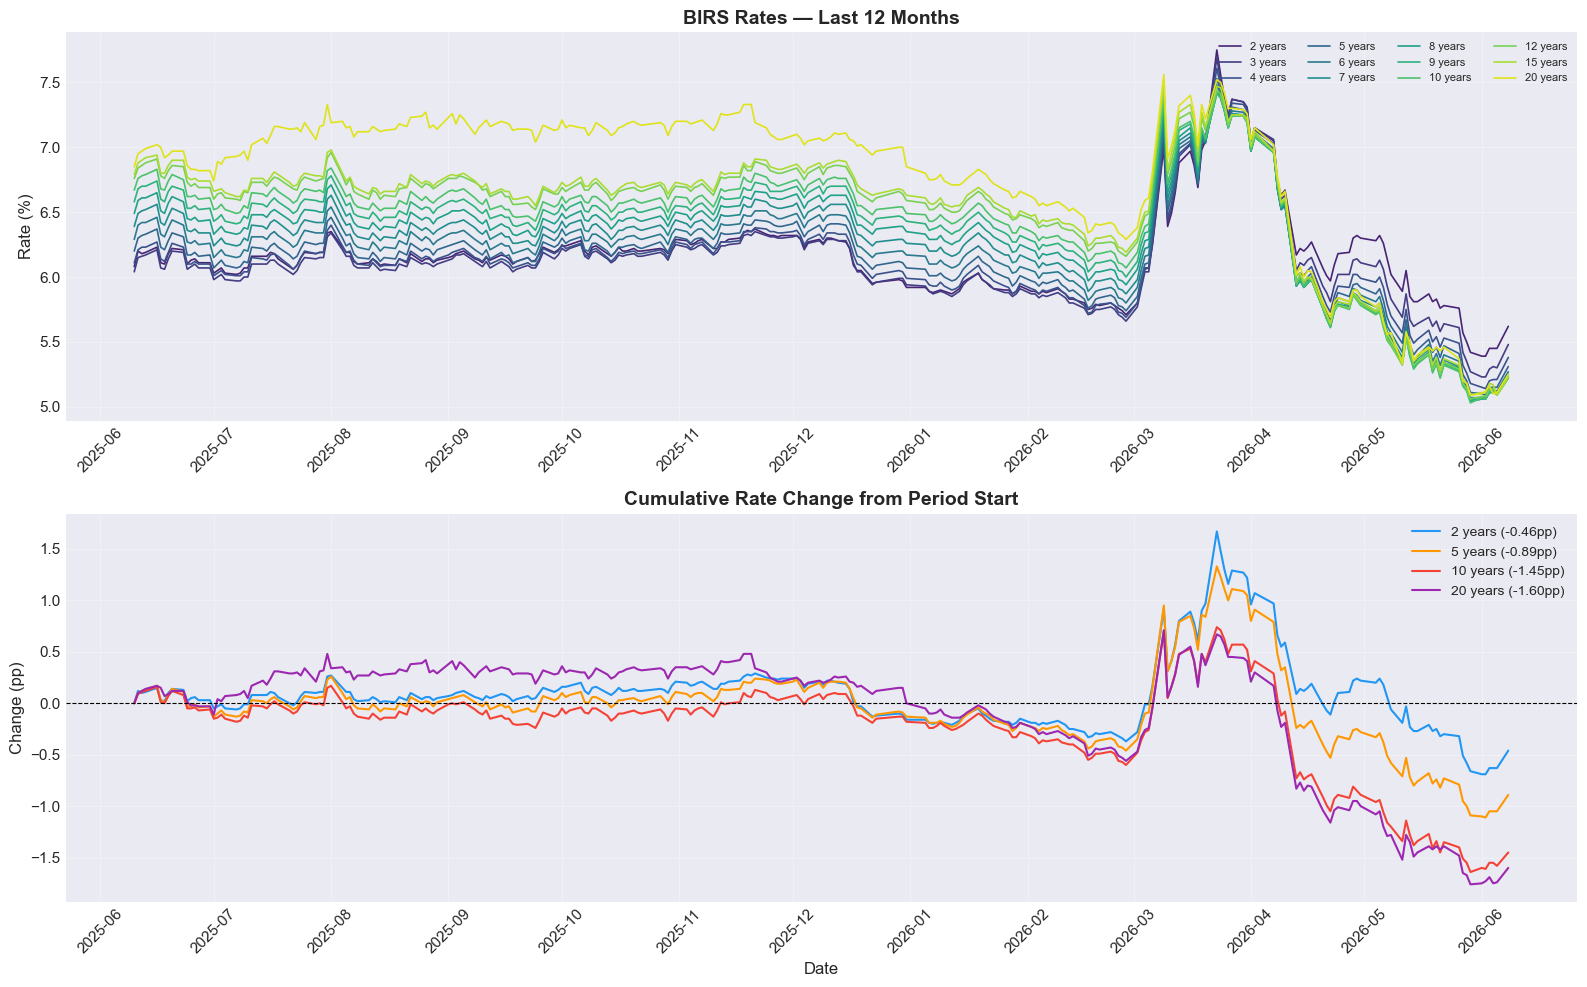

Recent 12-month summary:
       2 years  3 years  4 years  5 years  6 years  7 years  8 years  9 years  10 years  12 years  15 years  20 years
count  251.000  251.000  251.000  251.000  251.000  251.000  251.000  251.000   251.000   251.000   251.000   251.000
mean     6.163    6.115    6.126    6.160    6.212    6.267    6.325    6.381     6.434     6.510     6.542     6.779
std      0.347    0.370    0.383    0.395    0.408    0.424    0.439    0.455     0.471     0.489     0.491     0.587
min      5.390    5.230    5.140    5.090    5.070    5.050    5.050    5.040     5.030     5.060     5.090     5.090
25%      5.970    5.935    5.955    5.990    6.060    6.145    6.230    6.300     6.370     6.460     6.490     6.615
50%      6.150    6.100    6.120    6.190    6.260    6.340    6.420    6.500     6.570     6.660     6.690     7.040
75%      6.250    6.205    6.230    6.300    6.370    6.440    6.515    6.590     6.670     6.760     6.790     7.160
max      7.750    7.690    7.61

In [14]:
# Last 12 months
cutoff = df['date of fixing'].max() - pd.DateOffset(months=12)
recent = df[df['date of fixing'] >= cutoff].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Rates
for i, col in enumerate(tenor_cols):
    mask = recent[col].notna()
    if mask.any():
        axes[0].plot(recent.loc[mask, 'date of fixing'], recent.loc[mask, col],
                     label=col, color=COLORS[i], linewidth=1.2)

axes[0].set_title(f'BIRS Rates — Last 12 Months', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Rate (%)')
axes[0].legend(loc='upper right', ncol=4, fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Cumulative change from start of period
recent_start = recent.iloc[0]
for col, color in zip(['2 years', '5 years', '10 years', '20 years'],
                       ['#2196F3', '#FF9800', '#F44336', '#9C27B0']):
    if col in recent.columns and recent[col].notna().any():
        start_val = recent[col].dropna().iloc[0]
        cum_change = recent[col] - start_val
        mask = cum_change.notna()
        axes[1].plot(recent.loc[mask, 'date of fixing'], cum_change[mask],
                     label=f'{col} ({cum_change.dropna().iloc[-1]:+.2f}pp)',
                     color=color, linewidth=1.5)

axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Cumulative Rate Change from Period Start', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Change (pp)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Summary stats for recent period
print("Recent 12-month summary:")
print(recent[tenor_cols].describe().round(3).to_string())

## 📋 Summary

Key findings from this EDA:

1. **Coverage**: ~4,940 daily observations from Nov 2006 to Jun 2026, covering 11–12 tenors
2. **Rate range**: Rates have varied from sub-1% (2020–2021 low-rate era) to ~13%+ (2022 hiking cycle)
3. **Curve inversions**: The yield curve has been inverted for a significant portion of the dataset, particularly during crisis periods
4. **Fat tails**: Daily changes exhibit excess kurtosis — extreme moves are more frequent than a normal distribution would suggest
5. **Correlation**: Nearby tenors are highly correlated (>0.95), but short vs. long tenors can diverge meaningfully
6. **Volatility clustering**: Rate volatility shows clear clustering — calm periods alternate with turbulent ones

---
*Data source: Magyar Nemzeti Bank (MNB) — [BIRS reference rates](https://www.mnb.hu/monetaris-politika/penzpiaci-informaciok/referenciamutato-jegyzesi-bizottsag/birs)*